# HiResCAM — class activation maps (separate from training)

HiResCAM (Deng et al.) uses **ReLU** of the **sum over channels of (gradient × activation)** on the last spatial feature map — no spatial averaging of gradients (unlike Grad-CAM).

This notebook is **not** combined with `efficientnet_v2l.ipynb`. It reads `dataset/supplements` CSVs, loads files from **`dataset/images`** (override `IMAGES_DIR` if needed), and uses the **same** backbone layout (`EfficientNetV2L` with `pooling=None`, then `GlobalAveragePooling2D`, head) so weights saved from the training notebook load here.

Reference: [HiResCAM: Better class activation mapping without parameter tuning](https://arxiv.org/abs/2011.14291).

In [6]:
from pathlib import Path
from typing import Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

REPO_ROOT = Path("..").resolve()
SUPP = REPO_ROOT / "dataset" / "supplements"
IMAGES_DIR = REPO_ROOT / "dataset" / "images"

GT_CSV = SUPP / "training_gt.csv"
INPUT_CSV = SUPP / "training_input.csv"

LABEL_COLS = [
    "AKIEC", "BCC", "BEN_OTH", "BKL", "DF", "INF",
    "MAL_OTH", "MEL", "NV", "SCCKA", "VASC",
]

IMG_SIZE = 480
WEIGHTS_PATH: Optional[Path] = None  # e.g. Path("efficientnetv2l_best.weights.h5") from the other notebook

print("IMAGES_DIR:", IMAGES_DIR, "exists:", IMAGES_DIR.is_dir())

IMAGES_DIR: E:\RESEARCH_SHIT\MILK\dataset\images exists: True


In [7]:
def find_image_path(images_dir: Path, isic_id: str) -> Optional[Path]:
    for ext in (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"):
        p = images_dir / f"{isic_id}{ext}"
        if p.is_file():
            return p
    return None


def load_frame() -> pd.DataFrame:
    gt = pd.read_csv(GT_CSV)
    inp = pd.read_csv(INPUT_CSV)
    df = inp.merge(gt, on="lesion_id", how="inner")
    df["image_path"] = df["isic_id"].astype(str).map(lambda i: find_image_path(IMAGES_DIR, i))
    df = df.dropna(subset=["image_path"]).reset_index(drop=True)
    return df


df = load_frame()
print("rows with images:", len(df))
df.head(3)

rows with images: 10480


,lesion_id,image_type,isic_id,attribution,copyright_license,image_manipulation,age_approx,sex,skin_tone_class,site,...,BEN_OTH,BKL,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC,image_path
0,IL_0000652,clinical: close-up,ISIC_8149219,MILK study team,CC-BY-NC,altered,70.0,male,1,head_neck_face,...,0,0,0,0,0,0,0,0,0,E:\RESEARCH_SHIT\MILK\dataset\images\ISIC_8149...
1,IL_0000652,dermoscopic,ISIC_4671410,MILK study team,CC-BY-NC,instrument only,70.0,male,1,head_neck_face,...,0,0,0,0,0,0,0,0,0,E:\RESEARCH_SHIT\MILK\dataset\images\ISIC_4671...
2,IL_0003176,clinical: close-up,ISIC_3904045,MILK study team,CC-BY-NC,instrument only,45.0,female,5,head_neck_face,...,0,0,0,0,0,0,0,0,0,E:\RESEARCH_SHIT\MILK\dataset\images\ISIC_3904...


In [8]:
def build_classifier_and_cam(num_labels: int) -> Tuple[keras.Model, keras.Model]:
    base = keras.applications.EfficientNetV2L(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling=None,
    )
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    conv_out = base(inputs, training=False)
    pooled = layers.GlobalAveragePooling2D()(conv_out)
    x = layers.Dropout(0.2)(pooled)
    probs = layers.Dense(num_labels, activation="sigmoid")(x)
    classifier = keras.Model(inputs, probs, name="effv2l_multilabel")
    cam_model = keras.Model(inputs, [probs, conv_out], name="effv2l_cam")
    return classifier, cam_model


classifier, cam_model = build_classifier_and_cam(len(LABEL_COLS))

if WEIGHTS_PATH is not None and Path(WEIGHTS_PATH).is_file():
    classifier.load_weights(WEIGHTS_PATH)
    print("Loaded weights into shared layers:", WEIGHTS_PATH)
else:
    print("No WEIGHTS_PATH — ImageNet backbone + random head (train in the other notebook first).")

# classifier and cam_model share the same layer objects; load_weights above updates both.
classifier.summary()

No WEIGHTS_PATH — ImageNet backbone + random head (train in the other notebook first).
Model: "effv2l_multilabel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 480, 480, 3)]     0         
                                                                 
 efficientnetv2-l (Functiona  (None, 15, 15, 1280)     117746848 
 l)                                                              
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_1 (Dropout)         (None, 1280)              0         
                                                                 
 dense_1 (Dense)             (None, 11)                14091     
                            

In [9]:
def hires_cam_batch(cam_model: keras.Model, images: tf.Tensor, class_idx: int):
    images = tf.cast(images, tf.float32)
    with tf.GradientTape() as tape:
        preds, conv = cam_model(images, training=False)
        score = preds[:, class_idx]
    grads = tape.gradient(score, conv)
    cam = tf.reduce_sum(tf.multiply(grads, conv), axis=-1)
    cam = tf.nn.relu(cam)
    return preds, cam


def normalize_heatmap(h: np.ndarray) -> np.ndarray:
    h = h.astype(np.float32)
    hmin, hmax = h.min(), h.max()
    if hmax > hmin:
        h = (h - hmin) / (hmax - hmin)
    return h


def overlay_heatmap(rgb_uint8: np.ndarray, heatmap: np.ndarray, alpha: float = 0.45):
    h, w = rgb_uint8.shape[:2]
    hm = tf.image.resize(heatmap[..., None], [h, w], method="bilinear").numpy().squeeze()
    hm = normalize_heatmap(hm)
    color = (plt.get_cmap("jet")(hm)[..., :3] * 255).astype(np.float32)
    base = rgb_uint8.astype(np.float32)
    out = (1 - alpha) * base + alpha * color
    return np.clip(out, 0, 255).astype(np.uint8)

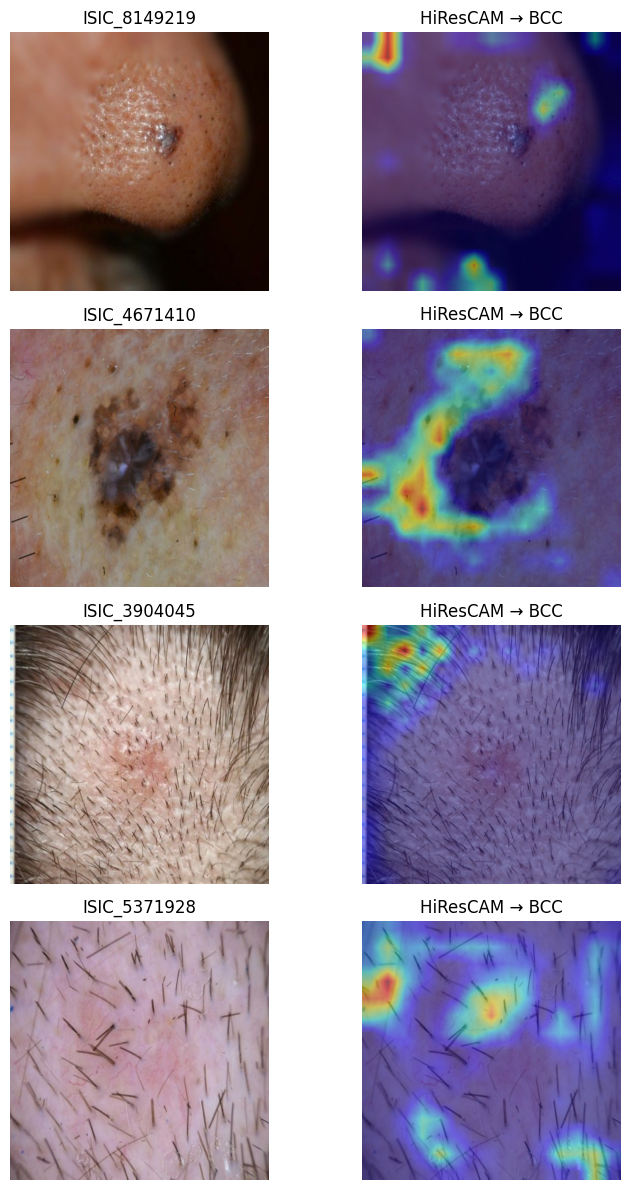

Top predicted labels (this row): ['AKIEC', 'MAL_OTH']


In [10]:
def preprocess(path_tensor):
    data = tf.io.read_file(path_tensor)
    img = tf.image.decode_image(data, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bilinear")
    return keras.applications.efficientnet_v2.preprocess_input(tf.cast(img, tf.float32))


if len(df) == 0:
    raise FileNotFoundError(f"No images found under {IMAGES_DIR}")

sample = df.head(4)
paths = [str(p) for p in sample["image_path"]]
batch = tf.stack([preprocess(tf.constant(p)) for p in paths], axis=0)

CLASS_IDX = 1  # e.g. BCC column in LABEL_COLS
preds, heat = hires_cam_batch(cam_model, batch, CLASS_IDX)
preds_np = preds.numpy()
heat_np = heat.numpy()

fig, axes = plt.subplots(len(paths), 2, figsize=(8, 3 * len(paths)))
if len(paths) == 1:
    axes = np.array([axes])
for i, p in enumerate(paths):
    raw = tf.image.decode_image(tf.io.read_file(p), channels=3, expand_animations=False)
    raw.set_shape([None, None, 3])
    raw = tf.image.resize(raw, [IMG_SIZE, IMG_SIZE]).numpy().astype(np.uint8)
    overlay = overlay_heatmap(raw, heat_np[i])
    axes[i, 0].imshow(raw)
    axes[i, 0].set_title(sample.iloc[i]["isic_id"])
    axes[i, 0].axis("off")
    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"HiResCAM → {LABEL_COLS[CLASS_IDX]}")
    axes[i, 1].axis("off")
plt.tight_layout()
plt.show()

print("Top predicted labels (this row):", [LABEL_COLS[j] for j in np.where(preds_np[0] > 0.5)[0]])

In [ ]:
# Recommended defaults for CAM analysis: align explanations with best exported model
BEST_WEIGHTS_PATH: Optional[Path] = Path("efficientnetv2l_best_stage3.weights.h5")
BEST_THRESHOLDS_PATH: Optional[Path] = Path("efficientnetv2l_multilabel_final_thresholds.npy")

if WEIGHTS_PATH is None and BEST_WEIGHTS_PATH.is_file():
    WEIGHTS_PATH = BEST_WEIGHTS_PATH

THRESHOLDS = None
if BEST_THRESHOLDS_PATH is not None and BEST_THRESHOLDS_PATH.is_file():
    THRESHOLDS = np.load(BEST_THRESHOLDS_PATH)
    print("Loaded thresholds:", BEST_THRESHOLDS_PATH)
else:
    print("Threshold file not found; CAM notebook will fall back to 0.5 per class.")

print("CAM weights path:", WEIGHTS_PATH)

In [ ]:
# Threshold-aware prediction helper for CAM inspection

def decode_predictions_with_thresholds(preds_np: np.ndarray):
    probs = preds_np[0]
    if THRESHOLDS is None:
        active = np.where(probs > 0.5)[0]
    else:
        active = np.where(probs > THRESHOLDS)[0]
    return [LABEL_COLS[j] for j in active]


print("Threshold-aware CAM helper ready.")
print("Use `decode_predictions_with_thresholds(preds_np)` instead of raw `prob > 0.5`.")